### **Environment and Dataset**

In [1]:
import pandas as pd
import numpy as np

files = [
    "../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "../data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "../data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "../data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "../data/Tuesday-WorkingHours.pcap_ISCX.csv",
    "../data/Wednesday-workingHours.pcap_ISCX.csv"
]

dfs = [pd.read_csv(file) for file in files]
df = pd.concat(dfs, ignore_index=True)
df.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [2]:
# functions
# Format large numbers into readable units
def format_number(value):

    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"

    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"

    else:
        return f"{value:.2f}"

In [3]:

df_columns = pd.DataFrame({
    "Column Name": df.columns,
    "White Space": (
        df.columns.str.len()
        -
        df.columns.str.strip().str.len()
    ),
    "Data Type": df.dtypes,
    "Non-Null Count": df.isnull().sum(),
}).reset_index(drop=True)
df_columns

,Column Name,White Space,Data Type,Non-Null Count
0,Destination Port,1,int64,0
1,Flow Duration,1,int64,0
2,Total Fwd Packets,1,int64,0
3,Total Backward Packets,1,int64,0
4,Total Length of Fwd Packets,0,int64,0
...,...,...,...,...
74,Idle Mean,0,float64,0
75,Idle Std,1,float64,0
76,Idle Max,1,int64,0
77,Idle Min,1,int64,0


In [4]:
# Based on the above table, We should strip the cols 
# and convert the label to category for better memory usage and performance

df.columns = df.columns.str.strip()

df["Label"] = df["Label"].astype("category")

In [5]:
df_columns = pd.DataFrame({
    "Column Name": df.columns,
    "White Space": (
        df.columns.str.len()
        -
        df.columns.str.strip().str.len()
    ),
    "Data Type": df.dtypes,
    "Non-Null Count": df.isnull().sum(),
}).reset_index(drop=True)

# Check the data type
df_columns[df_columns["Column Name"] == "Label"]

,Column Name,White Space,Data Type,Non-Null Count
78,Label,0,category,0


---

### **Attack Diversity Analysis**

Understanding attack distribution helps identify dominant threat vectors,
dataset imbalance risks, and potential challenges for ML-based detection systems.

In [6]:
df["Label"].value_counts()

Label
BENIGN                        1554112
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

#### Lets Create Attack Categories Table, and then Add Security Interpretation Column

In [7]:
attack_summary = (
    df["Label"]
    .value_counts()
    .reset_index()
)

attack_summary["Label"] = (
    attack_summary["Label"]
    .str.encode("utf-8", "ignore")
    .str.decode("utf-8")
)

attack_summary

,Label,count
0,BENIGN,1554112
1,DoS Hulk,231073
2,PortScan,158930
3,DDoS,128027
4,DoS GoldenEye,10293
5,FTP-Patator,7938
6,SSH-Patator,5897
7,DoS slowloris,5796
8,DoS Slowhttptest,5499
9,Web Attack � Brute Force,1507


In [8]:
attack_descriptions = {
    "BENIGN": "Legitimate normal network activity",
    "DoS Hulk": "High-volume HTTP flooding attack",
    "PortScan": "Reconnaissance scanning activity",
    "DDoS": "Distributed denial-of-service flooding attack",
    "DoS GoldenEye": "Web server resource exhaustion attack",
    "FTP-Patator": "FTP brute-force authentication attack",
    "SSH-Patator": "SSH brute-force authentication attack",
    "DoS slowloris": "Slow persistent connection exhaustion attack",
    "DoS Slowhttptest": "Slow HTTP request exhaustion attack",
    "Web Attack � Brute Force": "Website credential brute-force attack",
    "Web Attack � XSS": "Cross-site scripting injection attack",
    "Infiltration": "Internal compromise or lateral movement activity",
    "Web Attack � Sql Injection": "SQL injection exploitation attempt",
    "Heartbleed": "OpenSSL Heartbleed vulnerability exploitation"
}

attack_summary["Meaning"] = attack_summary["Label"].map(
    attack_descriptions
)

attack_summary

,Label,count,Meaning
0,BENIGN,1554112,Legitimate normal network activity
1,DoS Hulk,231073,High-volume HTTP flooding attack
2,PortScan,158930,Reconnaissance scanning activity
3,DDoS,128027,Distributed denial-of-service flooding attack
4,DoS GoldenEye,10293,Web server resource exhaustion attack
5,FTP-Patator,7938,FTP brute-force authentication attack
6,SSH-Patator,5897,SSH brute-force authentication attack
7,DoS slowloris,5796,Slow persistent connection exhaustion attack
8,DoS Slowhttptest,5499,Slow HTTP request exhaustion attack
9,Web Attack � Brute Force,1507,Website credential brute-force attack


---

## Behavioral Threat Analysis

In [9]:
# separate benign and malicious data.

benign_df = df[df["Label"] == "BENIGN"]
malicious_df = df[df["Label"] != "BENIGN"]

In [10]:
print(f"Inf values in Benign samples: {benign_df.isin([np.inf, -np.inf]).sum().sum()}")
print(f"Inf values in Malicious samples: {malicious_df.isin([np.inf, -np.inf]).sum().sum()}")

Inf values in Benign samples: 2139
Inf values in Malicious samples: 1211


In [11]:
traffic_behavior = pd.DataFrame({
    "Metric": [
        "Average Flow Duration",
        "Average Packets per Flow, mean(Fwd+Bwd)",
        "Average Bytes per Flow, mean(length of Fwd + Bwd)",
        "Average Flow Bytes/s",
        "Average Flow Packets/s"
    ],

    "Benign Traffic": [

        benign_df["Flow Duration"].mean(),

        (
            benign_df["Total Fwd Packets"] +
            benign_df["Total Backward Packets"]
        ).mean(),

        (
            benign_df["Total Length of Fwd Packets"] +
            benign_df["Total Length of Bwd Packets"]
        ).mean(),

        benign_df["Flow Bytes/s"].replace(
            [np.inf, -np.inf],
            np.nan
        ).mean(),

        benign_df["Flow Packets/s"].replace(
            [np.inf, -np.inf],
            np.nan
        ).mean()
    ],

    "Malicious Traffic": [

        malicious_df["Flow Duration"].mean(),

        (
            malicious_df["Total Fwd Packets"] +
            malicious_df["Total Backward Packets"]
        ).mean(),

        (
            malicious_df["Total Length of Fwd Packets"] +
            malicious_df["Total Length of Bwd Packets"]
        ).mean(),

        malicious_df["Flow Bytes/s"].replace(
            [np.inf, -np.inf],
            np.nan
        ).mean(),

        malicious_df["Flow Packets/s"].replace(
            [np.inf, -np.inf],
            np.nan
        ).mean()
    ],
    "Security Insight": [
        "Long durations may indicate persistent sessions or slow attacks.",

        "Attack traffic often generates abnormal packet volumes.",

        "Large byte transfers may indicate flooding or data exfiltration.",

        "High byte rates may indicate aggressive traffic behavior.",

        "Abnormal packet rates often appear during denial-of-service attacks."
    ]
})

traffic_behavior

,Metric,Benign Traffic,Malicious Traffic,Security Insight
0,Average Flow Duration,1.143847e+07,2.941929e+07,Long durations may indicate persistent session...
1,"Average Packets per Flow, mean(Fwd+Bwd)",2.215870e+01,7.374766e+00,Attack traffic often generates abnormal packet...
2,"Average Bytes per Flow, mean(length of Fwd + Bwd)",1.865430e+04,5.420959e+03,Large byte transfers may indicate flooding or ...
3,Average Flow Bytes/s,1.835860e+06,3.159144e+05,High byte rates may indicate aggressive traffi...
4,Average Flow Packets/s,6.570841e+04,9.582122e+04,Abnormal packet rates often appear during deni...


---
### **Analytical Visualization of Attack Distribution**

In [12]:
import matplotlib.pyplot as plt

attack_distribution = (
    df["Label"]
    .value_counts()
    .reset_index()
).sort_values(by="count", ascending=True)

# Calculate traffic percentages
attack_distribution["percentage"] = (
    attack_distribution["count"]
    / attack_distribution["count"].sum()
    * 100
).round(2)

attack_distribution

,Label,count,percentage
13,Heartbleed,11,0.00
12,Web Attack � Sql Injection,21,0.00
11,Infiltration,36,0.00
10,Web Attack � XSS,652,0.03
9,Web Attack � Brute Force,1507,0.07
8,DoS Slowhttptest,5499,0.26
7,DoS slowloris,5796,0.27
6,SSH-Patator,5897,0.28
5,FTP-Patator,7938,0.38
4,DoS GoldenEye,10293,0.49


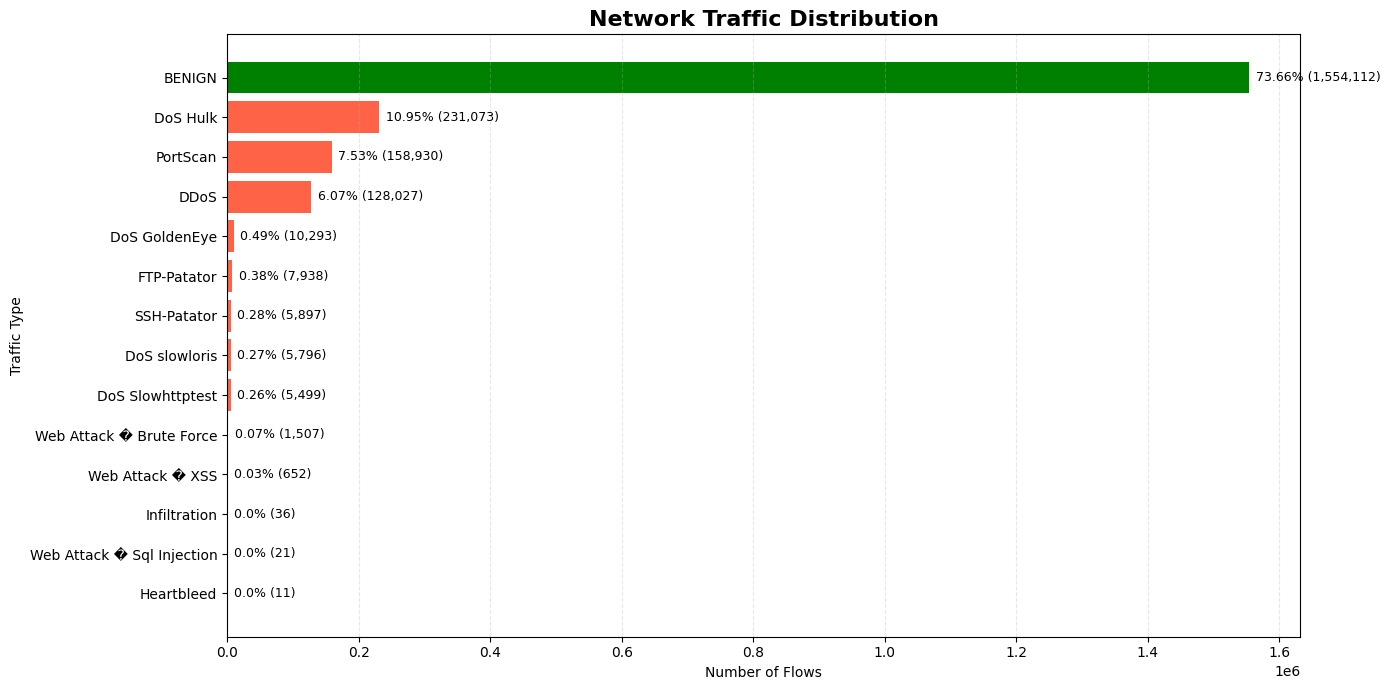

In [13]:

# Create custom colors
colors = [
    "green" if label == "BENIGN" else "tomato"
    for label in attack_distribution["Label"]
]

# Create figure
plt.figure(figsize=(14, 7))

# Create horizontal bar chart
bars = plt.barh(
    attack_distribution["Label"],
    attack_distribution["count"],
    color=colors
)

# Add chart title
plt.title(
    "Network Traffic Distribution",
    fontsize=16,
    fontweight="bold"
)

# Add axis labels
plt.xlabel("Number of Flows")
plt.ylabel("Traffic Type")

# Add grid
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Add percentages and counts beside bars
for bar, percentage, count in zip(
    bars,
    attack_distribution["percentage"],
    attack_distribution["count"]
):

    plt.text(
        bar.get_width() + 10000,
        bar.get_y() + bar.get_height() / 2,

        f"{percentage}% ({count:,})",

        va="center",
        fontsize=9
    )

# Improve spacing
plt.tight_layout()

# Show chart
plt.show()

## <font color='green'>Landscape Analysis</font>

#### Which attacks dominate the environment?
`DoS-based attacks` dominate the environment, particularly `DoS Hulk`, indicating strong volumetric attack behavior and significant traffic imbalance.

 `PortScan` (7.53%) and `DDoS` (6.07%).

This indicates that the simulated threat landscape is strongly focused on:
- traffic flooding,
- service exhaustion,
- and reconnaissance behavior.

At the same time, benign traffic still represents the majority of the environment at approximately 73.66%, which reflects

 a more realistic enterprise network scenario where malicious activity is mixed within normal operational traffic.


#### Why are DDoS and DoS attacks usually high-volume?
DoS and DDoS attacks rely on overwhelming systems through extremely large numbers of requests, packets, or connections.

Unlike stealth-focused attacks, denial-of-service attacks aim to:
- exhaust bandwidth,
- overload CPUs,
- consume memory,
- or saturate application resources.

As a result, they naturally generate:
- massive packet counts,
- abnormal flow rates,
- repetitive traffic patterns,
- and unusually dense connection activity.

This explains why these attacks dominate many network telemetry datasets.


#### Why is attack imbalance dangerous for ML classification?
The dataset shows a strong class imbalance, where some attack categories contain hundreds of thousands of flows while others contain only a few dozen samples.

For example:
- `DoS Hulk` contains over 231,000 flows,
- while `Heartbleed` contains only 11.

This imbalance is dangerous because machine learning models may become biased toward dominant attack patterns and fail to correctly detect rare but highly critical threats.

As a result:
- minority attacks may experience high false negative rates,
- detection reliability decreases,
- and production security systems become less trustworthy.

This is one of the biggest challenges in cybersecurity machine learning.


#### Why should SOC teams analyze traffic behavior instead of labels only?
Attack labels alone do not explain how malicious activity behaves inside the network.

Behavioral analysis focuses on:
- packet timing,
- flow duration,
- byte transfer patterns,
- connection frequency,
- protocol behavior,
- and TCP flag activity.

This is critical because attackers constantly change:
- payloads,
- IP addresses,
- signatures,
- and infrastructure.

However, behavioral anomalies often remain visible even when attack signatures evolve.

For this reason, modern SOC operations increasingly rely on:
- anomaly detection,
- behavioral analytics,
- and telemetry-based threat hunting
rather than static labels alone.


#### Which metrics appear most useful for behavioral detection?
Several features appear highly valuable for distinguishing malicious traffic from normal activity:

- `Flow Packets/s`
- `Flow Bytes/s`
- `Flow Duration`
- `Packet Length Mean`
- `Total Fwd Packets`
- `Total Backward Packets`
- `SYN Flag Count`
- `ACK Flag Count`
- `Flow IAT Mean`
- `Flow IAT Std`

These metrics help reveal:
- traffic flooding,
- automated scanning,
- abnormal connection timing,
- protocol abuse,
- and repetitive machine-generated communication patterns.

In particular:
- packet rates,
- timing intervals,
- and TCP flag behavior
are often strong indicators of malicious automation and denial-of-service activity.

---
### Threat Risk Scoring Engine

In [14]:
# Initialize Risk Score.
df["RiskScore"] = 0

#Add Base Threat Risk
df.loc[
    df["Label"] != "BENIGN",
    "RiskScore"
] += 1


#Add High Traffic Risk
packet_threshold = (
    (
        df["Total Fwd Packets"] +
        df["Total Backward Packets"]
    ).quantile(0.95)
)

df.loc[
    (
        df["Total Fwd Packets"] +
        df["Total Backward Packets"]
    ) > packet_threshold,
    "RiskScore"
] += 1

# Add Flow Duration Risk
duration_threshold = (
    df["Flow Duration"]
    .quantile(0.95)
)

df.loc[
    df["Flow Duration"] > duration_threshold,
    "RiskScore"
] += 1

# Add Abnormal Traffic Rate Risk
bytes_threshold = (
    df["Flow Bytes/s"]
    .replace([np.inf, -np.inf], np.nan)
    .quantile(0.95)
)

df.loc[
    df["Flow Bytes/s"] > bytes_threshold,
    "RiskScore"
] += 1

#Create Risk Levels
df.sort_values(by="RiskScore", ascending=False, inplace=True)
df["RiskScore"].value_counts()



RiskScore
0    1315785
1     715856
2      78102
3         49
Name: count, dtype: int64

In [15]:
#Create Risk Levels
def assign_risk_level(score):
    if score == 0:
        return "Low"
    elif score == 1:
        return "Medium"
    elif score == 2:
        return "High"
    else:
        return "Critical"

df["RiskLevel"] = df["RiskScore"].apply(
    assign_risk_level
)

risk_distribution = (
    df["RiskLevel"]
    .value_counts()
    .reset_index()
)

risk_distribution

,RiskLevel,count
0,Low,1315785
1,Medium,715856
2,High,78102
3,Critical,49


In [16]:
risk_distribution ['percent'] = round(risk_distribution['count'] / risk_distribution['count'].sum() * 100, 4)
risk_distribution

,RiskLevel,count,percent
0,Low,1315785,62.3656
1,Medium,715856,33.9302
2,High,78102,3.7019
3,Critical,49,0.0023


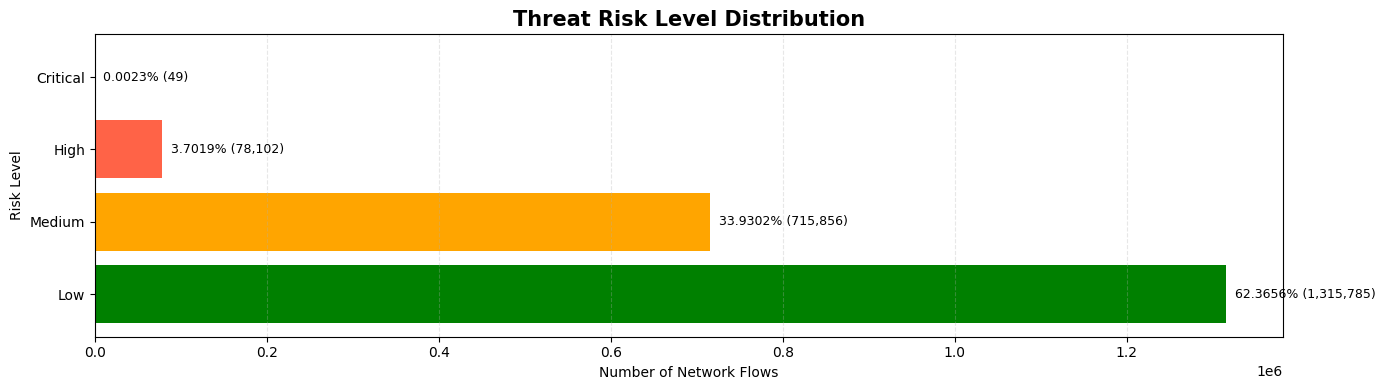

In [17]:
#import matplotlib.pyplot as plt

colors = {  "Critical": "darkred", 
            "High": "tomato", 
            "Medium": "orange", 
            "Low": "green"  }

# Create figure
plt.figure(figsize=(14, 4))

# Create horizontal bars
bars = plt.barh(
    risk_distribution["RiskLevel"],
    risk_distribution["count"],

    color=[
        colors[level]
        for level in risk_distribution["RiskLevel"]
    ]
)

# Add title
plt.title(
    "Threat Risk Level Distribution",
    fontsize=15,
    fontweight="bold"
)

# Add axis labels
plt.xlabel("Number of Network Flows")
plt.ylabel("Risk Level")

# Add grid
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Add percentages beside bars
for bar, percent, count in zip(
    bars,
    risk_distribution["percent"],
    risk_distribution["count"]
):

    plt.text(
        bar.get_width() + 10000,

        bar.get_y() + bar.get_height() / 2,

        f"{percent:.4f}% ({count:,})",

        va="center",
        fontsize=9
    )

# Improve spacing
plt.tight_layout()

# Show chart
plt.show()

### Risk Prioritization Analysis

`Security Operations Centers` (SOC) process extremely large volumes of alerts and network events every day. `Risk prioritization` helps analysts focus first on the most `dangerous` and operationally significant threats instead of treating all traffic equally.

Without prioritization:
- alert fatigue increases,
- critical incidents may be overlooked,
- and response times become slower.

`Risk-based workflows` allow SOC teams to allocate resources more `efficiently` and respond to high-severity threats faster.


`Behavioral metrics` capture how network traffic behaves rather than relying only on predefined attack signatures.

Metrics such as:
- packet rates,
- flow duration,
- connection density,
- byte transfer rates,
- and TCP flag activity

help identify abnormal communication patterns commonly associated with malicious automation and attack activity.

`Behavioral scoring` is especially valuable because attackers frequently modify payloads and infrastructure while underlying behavioral anomalies often remain detectable.


`Static signature detection` depends on previously known attack patterns. While effective against known threats, it struggles against:
- zero-day attacks,
- polymorphic malware,
- encrypted payloads,
- and rapidly evolving attacker techniques.

`Modern attackers` can easily modify:
- file hashes,
- IP addresses,
- payload structures,
- and command signatures.

As a result, relying solely on signatures creates detection gaps and increases the likelihood of missed attacks.


Several `behavioral characteristics` appear strongly associated with elevated risk levels:

- unusually high packet rates,
- abnormal flow durations,
- excessive forward packet counts,
- suspicious TCP flag activity,
- repetitive connection behavior,
- and irregular timing intervals between packets.

In particular, `high-volume DoS` and `DDoS` traffic generated dense and repetitive communication patterns that significantly increased risk scores.


This system can help incident response teams rapidly identify suspicious traffic patterns and prioritize investigations based on behavioral severity.

The risk `classification process` enables teams to:
- isolate high-risk traffic faster,
- reduce investigation time,
- detect anomalies earlier,
- identify emerging attack behavior,
- and improve operational efficiency during large-scale security events.

By combining `statistical analysis` with `behavioral indicators`, the system provides a more scalable and proactive approach to network threat detection.

---

### **Machine Learning Threat Detection**

In [18]:
df_copy = df.copy()

inf_rows_cols = df.copy().loc[
    df_copy.isin([np.inf, -np.inf]).any(axis=1),
    df_copy.columns[
        df_copy.isin([np.inf, -np.inf]).any()
    ]
]

inf_rows_cols

,Flow Bytes/s,Flow Packets/s
380014,inf,inf
377020,inf,inf
318188,inf,inf
345784,inf,inf
349232,inf,inf
...,...,...
2046581,NaN,inf
2070642,NaN,inf
6796,NaN,inf
2088101,NaN,inf


In [19]:
df_ml = df.copy()
print(f"Infinite and null values in df_ml: {df_ml.isin([np.inf, -np.inf, np.nan]).sum().sum()}")
df_ml = df_ml.replace(
    [np.inf, -np.inf],
    np.nan
)

df_ml = df_ml.dropna()  # Drop rows with NaN vals, it is a quick way to clean the data for ML modeling, 
                        # but we can also consider `imputation`` or `capping`` for a more nuanced approach.
                        
print(f"Infinite values in df_ml after cleaning: {df_ml.isin([np.inf, -np.inf]).sum().sum()}")
print(f"Null values in df_ml after cleaning: {df_ml.isnull().sum().sum()}")

Infinite and null values in df_ml: 4616
Infinite values in df_ml after cleaning: 0
Null values in df_ml after cleaning: 0


In [20]:
# Import LabelEncoder to convert categorical attack labels
# into numeric values required by machine learning algorithms.
from sklearn.preprocessing import LabelEncoder

#--------------------------------------------------------------------------
# Initialize LabelEncoder and create a new numeric target column.
# Each attack category is assigned a unique integer value.
label_encoder = LabelEncoder()
df_ml["AttackLabel"] = label_encoder.fit_transform(df_ml["Label"])

#--------------------------------------------------------------------------
# Columns excluded from the feature set.
features_to_drop = [
    "Label",        # 'Label' is the original target column.
    "AttackLabel",  # 'AttackLabel' is the encoded target used for prediction.
    "RiskLevel"     # 'RiskLevel' is a derived variable that could introduce data leakage.
]

#--------------------------------------------------------------------------
# Create the feature matrix (X) containing only network
# behavioral characteristics used for model training.
X = df_ml.drop(
    columns=features_to_drop,
    errors="ignore"
)

#--------------------------------------------------------------------------
# Create the target vector (y) containing the encoded
# attack classes the model will learn to predict.
y = df_ml["AttackLabel"]

In [21]:
#y.value_counts()


In [22]:
# Select only numeric columns for modeling, 
# as machine learning algorithms typically require numeric input.
X = X.select_dtypes(include=np.number)

# Check the data types of the features to ensure they are all numeric.
X.dtypes.value_counts()

int64      55
float64    24
Name: count, dtype: int64

**Train/Test Split**

In [23]:
# Import train_test_split to split the dataset into
# training and testing subsets for model evaluation.
from sklearn.model_selection import train_test_split

# Split the feature matrix (X) and target vector (y)
# into training and testing datasets.
#
# test_size=0.2:
#     Reserve 20% of the data for testing and use
#     the remaining 80% for model training.
#
# random_state=42:
#     Ensure reproducible results by using the same
#     random split every time the code is executed.
#
# stratify=y:
#     Preserve the original class distribution in both
#     training and testing sets. This is especially
#     important for imbalanced cybersecurity datasets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # 
)

In [24]:
# Verify the resulting dataset sizes.
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")

# Verify that class proportions were preserved.
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training samples: 1,685,987
Testing samples: 421,497

Training class distribution:
AttackLabel
0     73.684257
3     10.919361
9      7.535230
1      6.074780
2      0.488379
6      0.376515
10     0.279777
5      0.275032
4      0.260915
11     0.071531
13     0.030961
8      0.001720
12     0.001008
7      0.000534
Name: proportion, dtype: float64

Testing class distribution:
AttackLabel
0     73.684273
3     10.919413
9      7.535285
1      6.074776
2      0.488497
6      0.376515
10     0.279955
5      0.274972
4      0.260975
11     0.071412
13     0.030842
8      0.001661
12     0.000949
7      0.000474
Name: proportion, dtype: float64


**Class Imbalance Considerations**<br>
One of the most important characteristics of the CICIDS2017 dataset is its highly imbalanced class distribution. While benign traffic and<br>common attack types such as DoS Hulk,<br>PortScan, and DDoS account for the majority of observations, several attack categories—including 

Heartbleed, SQL Injection, and Infiltration—are represented by only a small number of samples.

This imbalance introduces several machine learning challenges:

- Models may become biased toward majority classes.
- High overall accuracy can be misleading if minority attacks are poorly detected.
- Rare but critical attack types may be overlooked during training.
- Performance evaluation should extend beyond accuracy and include metrics such as Precision, Recall, F1-Score, and the Confusion Matrix.

To mitigate this issue during model development, the dataset is split using stratified sampling (`stratify=y`). Stratification preserves<br>the original class proportions in both training and testing datasets, ensuring that minority attack classes remain represented throughout the evaluation process.

From a cybersecurity perspective, class imbalance reflects real-world network environments where malicious activity represents only a small<br>
fraction of overall traffic. Therefore, developing models that can accurately identify rare attacks is often more valuable than maximizing<br>
overall accuracy.

`Key Insight:` In intrusion detection systems, the `ability to detect rare but high-impact threats` is typically <u>more important</u> than achieving

 high accuracy on abundant benign traffic.

**Train Random Forest Model**

In [25]:
# Import the Random Forest classifier.
# Random Forest is an ensemble learning algorithm that combines
# multiple decision trees to improve prediction accuracy and robustness.
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model.
#
# n_estimators=100:
#     Build 100 decision trees and combine their predictions.
#
# random_state=42:
#     Ensure reproducible model training results.
#
# n_jobs=-1:
#     Utilize all available CPU cores to accelerate training.
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model using the training dataset.
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**Generate Predictions**

In [26]:
y_pred = rf_model.predict(X_test)

**Evaluate Model**

In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the Random Forest model: {accuracy}")
print(f"Accuracy: {accuracy:.2%}")

Accuracy of the Random Forest model: 0.9995468532397621
Accuracy: 99.95%


In [28]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    310577
           1       1.00      1.00      1.00     25605
           2       1.00      1.00      1.00      2059
           3       1.00      1.00      1.00     46025
           4       1.00      0.99      0.99      1100
           5       0.99      1.00      1.00      1159
           6       1.00      1.00      1.00      1587
           7       1.00      1.00      1.00         2
           8       1.00      0.71      0.83         7
           9       1.00      1.00      1.00     31761
          10       1.00      1.00      1.00      1180
          11       0.72      0.83      0.77       301
          12       0.25      0.25      0.25         4
          13       0.44      0.27      0.33       130

    accuracy                           1.00    421497
   macro avg       0.89      0.86      0.87    421497
weighted avg       1.00      1.00      1.00    421497



#### Random Forest Performance

The Random Forest model achieved an accuracy of **99.95%**, demonstrating excellent performance in distinguishing between benign <br>and malicious network traffic. The model also achieved near-perfect Precision, Recall, and F1-Scores for the majority of attack classes.

However, performance decreased for a few rare attack categories due to severe class imbalance. This is reflected in the difference<br> between the **Weighted F1-Score (1.00)** and the **Macro F1-Score (0.87)**, indicating that minority attack classes remain more challenging to detect.

> `Key Insight:`<br> While the model performs exceptionally well overall, additional techniques may be required to improve detection of rare but potentially high-impact attacks.

In [29]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance["Importance (%)"] = (
    feature_importance["Importance"] * 100
).round(2).astype(str) + " %"

feature_importance

,Feature,Importance,Importance (%)
0,RiskScore,0.115849,11.58 %
1,Total Length of Fwd Packets,0.047897,4.79 %
2,Bwd Packet Length Mean,0.043904,4.39 %
3,Packet Length Variance,0.043507,4.35 %
4,Bwd Packet Length Std,0.037892,3.79 %
...,...,...,...
74,Bwd Avg Packets/Bulk,0.000000,0.0 %
75,Fwd Avg Bytes/Bulk,0.000000,0.0 %
76,Fwd Avg Packets/Bulk,0.000000,0.0 %
77,Bwd Avg Bytes/Bulk,0.000000,0.0 %


**Visualize Top Features**

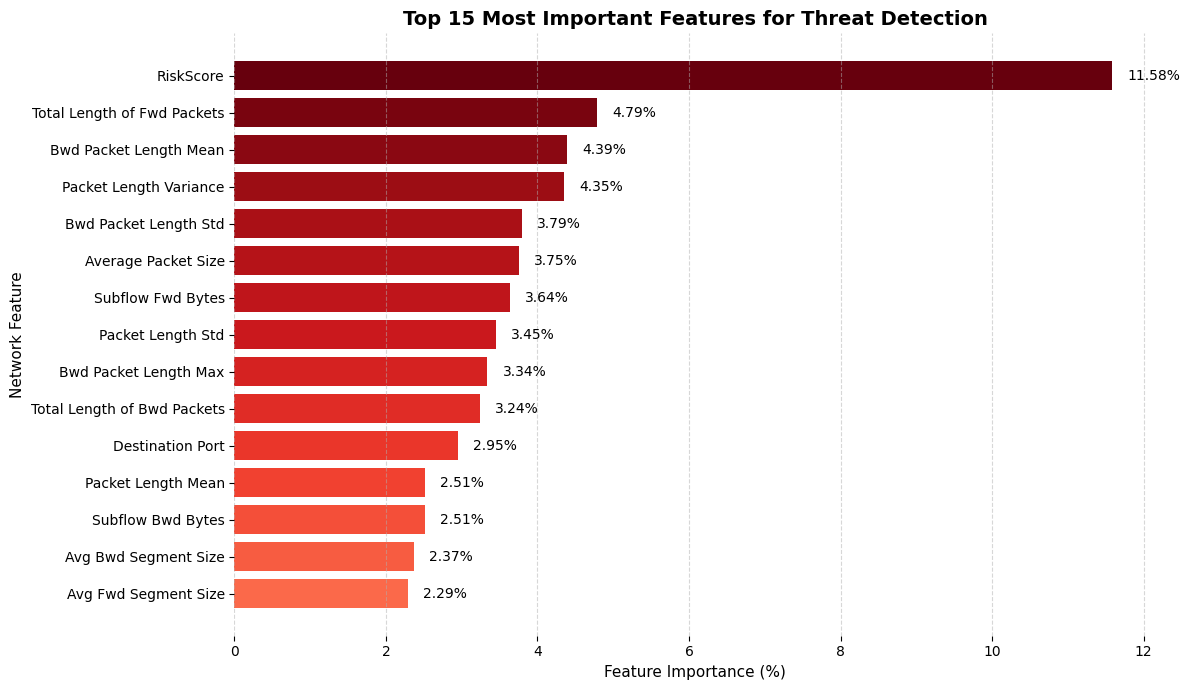

In [30]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(12, 7))


colors = plt.cm.Reds(
    np.linspace(1, 0.5, len(top_features))
)


bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"] * 100,
    color=colors
)

plt.gca().invert_yaxis()

# Add percentage labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center"
    )

plt.title(
    "Top 15 Most Important Features for Threat Detection",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Feature Importance (%)",
    fontsize=11
)

plt.ylabel(
    "Network Feature",
    fontsize=11
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.box(False)

plt.tight_layout()

plt.show()

<hr>

### **SOC Investigation & Threat Hunting**

In [31]:
high_risk_flows = df.loc[
    df["RiskLevel"] == "Critical"
].copy()

print(f"Highest Risk Traffic: {len(high_risk_flows):,}")

Highest Risk Traffic: 49


In [32]:
critical_attack_distribution = (
    high_risk_flows["Label"]
    .value_counts()
    .reset_index()
)

critical_attack_distribution

,Label,count
0,BENIGN,25
1,Infiltration,13
2,Heartbleed,10
3,PortScan,1
4,DDoS,0
5,DoS GoldenEye,0
6,DoS Hulk,0
7,DoS Slowhttptest,0
8,DoS slowloris,0
9,FTP-Patator,0


>**Observations**<br>
-Although there are some traffic flows that appear `suspicious` according to our `behavioral rules` and were classified as `Critical`<br>despite being labeled as `BENIGN`, the critical-risk category is mainly dominated by **`Infiltration`** and **`Heartbleed`** attacks.
<br>
-These attacks exhibit the most `abnormal network behavior` in the dataset, resulting in the `highest risk scores`. The presence<br>of several BENIGN flows within this category demonstrates that `behavior-based detection` identifies suspicious activity patterns <br>rather than `relying solelyon known attack labels`, which may lead to false positives that require analyst review.

**Threat Hunting Table**

In [33]:
threat_hunting_summary = (
    high_risk_flows.groupby("Label")
    .agg({
        "Flow Duration": "mean",
        "RiskScore": "mean"
    })
    .round(2)
)

threat_hunting_summary

,Flow Duration,RiskScore
Label,,
BENIGN,1.198850e+08,3.0
Heartbleed,1.192757e+08,3.0
Infiltration,1.158250e+08,3.0
PortScan,1.082593e+08,3.0


**Top Suspicious Flows**

In [35]:
suspicious_flows = (
    df.sort_values(
        by="RiskScore",
        ascending=False
    )
    .head(20)
)

suspicious_flows[
    [
        "Label",
        "RiskScore",
        "Flow Duration",
        "Flow Bytes/s"
    ]
].reset_index(drop=True)

,Label,RiskScore,Flow Duration,Flow Bytes/s
0,Heartbleed,3,119261118,6.617245e+04
1,Heartbleed,3,119296592,6.615277e+04
2,Heartbleed,3,119257653,6.568339e+04
3,BENIGN,3,119996804,4.931743e+06
4,Heartbleed,3,119262215,6.617223e+04
5,Heartbleed,3,119259886,6.617313e+04
6,Heartbleed,3,119259012,6.617362e+04
7,PortScan,3,108259271,0.000000e+00
8,BENIGN,3,119981343,4.182319e+06
9,Heartbleed,3,119302728,6.341193e+04


#### Threat Hunting Findings

Although there are some traffic flows labeled as BENIGN that appear suspicious according to the behavioral risk-scoring rules, the Critical-risk category is primarily dominated by **Heartbleed** activity. These flows consistently exhibit highly abnormal network behavior and repeatedly trigger the highest risk score.

The analysis also reveals that several BENIGN flows received Critical-risk ratings due to unusually long session durations and exceptionally high traffic throughput. This demonstrates an important principle of threat hunting: abnormal behavior does not always indicate a confirmed attack, but it often warrants investigation.

Across the Critical-risk category, the most common suspicious characteristics include:

- Extremely long flow durations
- Abnormally high traffic throughput (Flow Bytes/s)
- Unusual communication patterns
- Significant deviations from typical network behavior

From a SOC perspective, analysts should prioritize Heartbleed-related activity while also investigating behaviorally anomalous BENIGN flows, as they may represent misclassified threats, unauthorized activity, or previously unseen attack techniques.

> **Key Insight:** Effective threat hunting focuses on identifying abnormal behavior rather than relying solely on attack labels. High-risk behavioral anomalies often provide the earliest indicators of potential security incidents.

**Confusion Matrix**

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[310577,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0],
       [     1,  25603,      0,      1,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0],
       [     2,      0,   2053,      2,      2,      0,      0,      0,
             0,      0,      0,      0,      0,      0],
       [     2,      0,      4,  46017,      0,      0,      0,      0,
             0,      2,      0,      0,      0,      0],
       [     1,      0,      1,      0,   1089,      9,      0,      0,
             0,      0,      0,      0,      0,      0],
       [     1,      0,      0,      0,      0,   1157,      0,      0,
             0,      0,      0,      0,      1,      0],
       [     0,      0,      0,      0,      0,      0,   1587,      0,
             0,      0,      0,      0,      0,      0],
       [     0,      0,      0,      0,      0,      0,      0,      2,
             0,      0,  

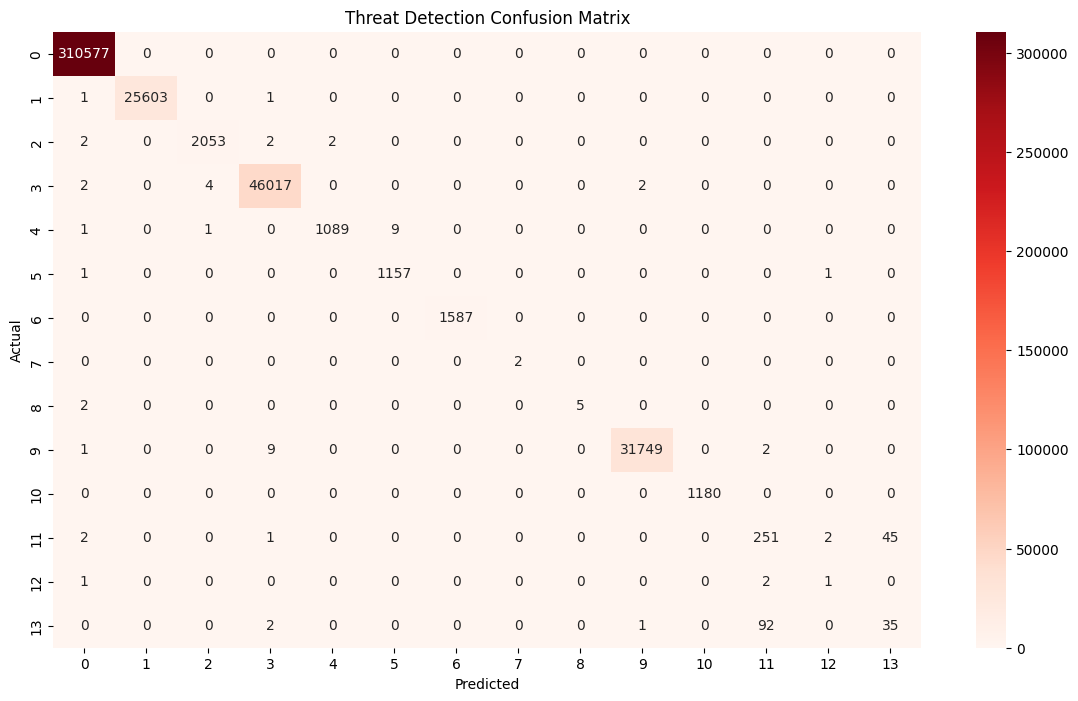

In [40]:
import seaborn as sns

plt.figure(figsize=(14,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title(
    "Threat Detection Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#### **Detection Quality Assessment**

The confusion matrix indicates that the Random Forest model achieves excellent overall classification performance, correctly identifying the vast majority of benign and malicious traffic flows. Most attack categories exhibit very strong detection rates, with predictions concentrated along the diagonal of the matrix, indicating successful classification.

**Which attacks are hardest to classify?**

The most challenging attack classes are the minority categories with limited training samples. In particular, classes **12** and **13** exhibit the lowest Precision, Recall, and F1-Scores. The confusion matrix shows that these attacks are frequently misclassified as class **11**, suggesting that they share similar behavioral characteristics and are difficult for the model to distinguish reliably.

**Why do false positives matter?**

False positives occur when legitimate traffic is incorrectly classified as malicious. In SOC environments, excessive false positives can overwhelm analysts, increase alert fatigue, and waste valuable investigation resources. Over time, analysts may become desensitized to alerts, increasing the risk of overlooking genuine threats.

**Why do false negatives matter even more?**

False negatives occur when malicious traffic is incorrectly classified as benign. These errors are generally more dangerous because they allow real attacks to remain undetected. In practice, a single missed intrusion may result in unauthorized access, data theft, service disruption, or long-term compromise of critical systems.

**Which attack classes would you prioritize improving?**

Priority should be given to the attack classes with the lowest detection performance, particularly the rare attack categories represented by classes **11**, **12**, and **13**. These classes exhibit the highest levels of confusion and would likely benefit from additional training samples, class balancing techniques, feature engineering, or targeted model tuning.

**How could this model support a SOC team?**

This model could serve as an effective first-line detection mechanism by automatically classifying large volumes of network traffic and highlighting potentially malicious activity for further investigation. Its strong performance on common attack types makes it valuable for reducing analyst workload and accelerating threat detection. Combined with behavioral analytics and SIEM monitoring, the model could help SOC teams prioritize alerts, identify suspicious traffic patterns, and respond more quickly to emerging threats.

> **Key Insight:** The model demonstrates excellent detection capability for the majority of attack categories, but the confusion matrix reveals that rare attack classes remain the most difficult to identify accurately. Improving detection of these minority threats would significantly enhance the overall effectiveness of the intrusion detection system.

## Feature Importance Analysis

Feature importance analysis reveals the network characteristics that contributed most to the model's classification decisions. The most influential features were primarily related to traffic volume, packet size, session behavior, and communication patterns.

Key features such as `RiskScore`, `Total Length of Fwd Packets`, `Packet Length Variance`, `Average Packet Size`, and `Flow Bytes/s` played a significant role in distinguishing benign traffic from malicious activity.

The results suggest that attacks often exhibit abnormal traffic volume, unusual packet characteristics, and irregular communication behavior when compared to legitimate network activity. These behavioral indicators provide valuable signals for identifying potential threats without relying solely on predefined attack signatures.

> **Key Insight:** The model relies primarily on behavioral network characteristics rather than attack-specific signatures, demonstrating the effectiveness of `behavior-based threat detection`.